In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import yfinance as yf
import datetime
import warnings
from matplotlib.patches import Patch
warnings.filterwarnings('ignore')

Necessary Functions

In [3]:
def data_collector(ticker:dict, start_date:datetime, end_date:datetime):
    data = yf.download(list(ticker.keys()), start = start_date, end = end_date)
    data = data.stack().reset_index()
    data.columns = ['Date', 'Ticker', 'Close', 'High', 'Low', 'Open', 'Volume']
    data['Pick'] = data['Ticker'].map(ticker)
    sp = yf.download('^GSPC', start=start_date, end=end_date)
    sp = sp.stack().reset_index()
    sp.columns = ['Date', 'Ticker', 'Close', 'High', 'Low', 'Open', 'Volume']
    data2 = pd.merge(data, sp, on='Date', how='left', suffixes=('', '_SP'))
    if data2['Close_SP'].isnull().any():
        data2['Close_SP'] = data2['Close_SP'].fillna(method='ffill')
    if data2['Open_SP'].isnull().any():
        data2['Open_SP'] = data2['Open_SP'].fillna(method='ffill')
    return data2

In [4]:
def performance_stock(ticker:str, data:pd.DataFrame):
    pick = data[data['Ticker'] == ticker]['Pick'].iloc[0]
    change = data[(data['Ticker'] == ticker) & (data['Date'] == data['Date'].max())]['Close'].reset_index(drop = True)[0] - data[(data['Ticker'] == ticker) & (data['Date'] == data['Date'].min())]['Open'].reset_index(drop = True)[0]
    if pick == 'Sell':
        ret = -change /data[(data['Ticker'] == ticker) & (data['Date'] == data['Date'].min())]['Open'].reset_index(drop = True)[0] * 100
    else:
        ret = change / data[(data['Ticker'] == ticker) & (data['Date'] == data['Date'].min())]['Open'].reset_index(drop = True)[0] * 100
    sp_change = data[(data['Ticker'] == ticker) & (data['Date'] == data['Date'].max())]['Close_SP'].reset_index(drop = True)[0] - data[(data['Ticker'] == ticker) & (data['Date'] == data['Date'].min())]['Open_SP'].reset_index(drop = True)[0]
    sp_ret = sp_change / data[(data['Ticker'] == ticker) & (data['Date'] == data['Date'].min())]['Open_SP'].reset_index(drop = True)[0] * 100
    return ret, pick, sp_ret

In [5]:
def results_summary(data:pd.DataFrame, tickers:dict):
    results = {ticker: performance_stock(ticker, data) for ticker in list(tickers.keys())}
    return pd.DataFrame(results, index=['Return (%)', 'Pick', 'SP Return (%)']).T

In [6]:
def merge_and_evaluate(results_list:list, key_list:list, tol:float): 
    all_results = pd.concat(results_list, keys=key_list)
    all_results.index.names = ['Date', 'Ticker']
    all_results['Success'] = np.where((all_results['Pick'] == 'Buy') & (all_results['Return (%)'] - all_results['SP Return (%)'] > tol), 1,
                                np.where((all_results['Pick'] == 'Sell') & (all_results['Return (%)'] - all_results['SP Return (%)'] > tol), 1, 
                                         np.where((all_results['Pick'] == 'Hold') & (abs(all_results['Return (%)'] - all_results['SP Return (%)']) <= tol), 1,
                                         0)))
    return all_results

In [7]:
def plot_results(data:pd.DataFrame, tickers:dict, steps:int):
    plt.figure(figsize=(10, 6))
    for ticker in tickers.keys():
        ticker_data = data[data['Ticker'] == ticker]
        ticker_data['Vals_base'] = ticker_data['Close'] / ticker_data['Close'].iloc[0] * 100
        plt.plot(ticker_data['Date'], ticker_data['Vals_base'], label=f"{ticker} Base Value", linewidth=2)
    sp_data = data[data['Ticker'] == list(tickers.keys())[0]]
    sp_data['Vals_base_SP'] = sp_data['Close_SP'] / sp_data['Close_SP'].iloc[0] * 100
    plt.plot(sp_data['Date'], sp_data['Vals_base_SP'], label="S&P 500 Base Value", linestyle='--', linewidth=2)
    plt.hlines(100, xmin=data['Date'].min(), xmax=data['Date'].max(), colors='black', linestyles='dotted')
    plt.title("Stock and S&P 500 Performance")
    plt.xlabel("Date")
    plt.ylabel("Base Value % change")
    plt.legend()
    plt.xticks(ticks=np.arange(data['Date'].min(), data['Date'].max(), step=datetime.timedelta(days=steps)))
    plt.show()

In [8]:
def performance_by_date(data:pd.DataFrame, date:str, weight_buy:float, weight_sell:float, weight_hold:float):
    if weight_buy + weight_sell + weight_hold == 1:
        date_data = data[data.index.get_level_values('Date') == date]
        weight_buy_return = pd.Series(0, index=date_data.index)
        weight_sell_return = pd.Series(0, index=date_data.index)
        weight_hold_return = pd.Series(0, index=date_data.index)
        for i in range(len(date_data)):
            if date_data['Pick'].iloc[i] == 'Buy':
                weight_buy_return.iloc[i] = date_data['Return (%)'].iloc[i] * weight_buy
            elif date_data['Pick'].iloc[i] == 'Sell':
                weight_sell_return.iloc[i] = date_data['Return (%)'].iloc[i] * weight_sell
            else:
                weight_hold_return.iloc[i] = date_data['Return (%)'].iloc[i] * weight_hold
        avg_return = weight_buy_return.sum() + weight_sell_return.sum() + weight_hold_return.sum() 
        avg_sp_return = date_data['SP Return (%)'].mean()
        return avg_return, avg_sp_return
    else: print("Weights must sum up to 1")


In [9]:
def plot_all_results(data:pd.DataFrame, date_list:list, weight_buy:float, weight_sell:float, weight_hold:float):
    plt.figure(figsize=(10,6))
    avg_sp_returns = []
    for date in date_list:
        avg_return, avg_sp_return = performance_by_date(data, date, weight_buy, weight_sell, weight_hold)
        avg_sp_returns.append(avg_sp_return)
        plt.bar(date, avg_return, color = 'green' if avg_return > 0 else 'red') 
    plt.plot(date_list, avg_sp_returns, '-x', label=f'SP Return', color = 'black')
    plt.hlines(0, xmin=date_list[0], xmax=date_list[-1], colors='black')
    legend_elements = [
        plt.Line2D([0], [0], marker='x', color='black', label='SP Return', linestyle='-', markersize=8),
        Patch(facecolor='green', label='FT Return (Positive)'),
        Patch(facecolor='red', label='FT Return (Negative)')
    ]
    plt.legend(handles=legend_elements)
    plt.xlabel('Date')
    plt.ylabel('Average Return (%)')
    plt.title('Average Return of FT Picks vs SP Return by Date of Pick')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

October 3rd 2025

In [10]:
ticker_031025 = {'MAB1.L':'Buy', 'JHD.L':'Buy', 'CARD.L':'Hold'}

In [11]:
data_031025 = data_collector(ticker_031025, '2025-10-03', datetime.date.today())

[*********************100%***********************]  3 of 3 completed
[*********************100%***********************]  1 of 1 completed


In [12]:
results_031025 = results_summary(data_031025, ticker_031025)
results_031025

,Return (%),Pick,SP Return (%)
MAB1.L,-10.055866,Buy,2.331694
JHD.L,-12.421248,Buy,2.331694
CARD.L,-28.165281,Hold,2.331694


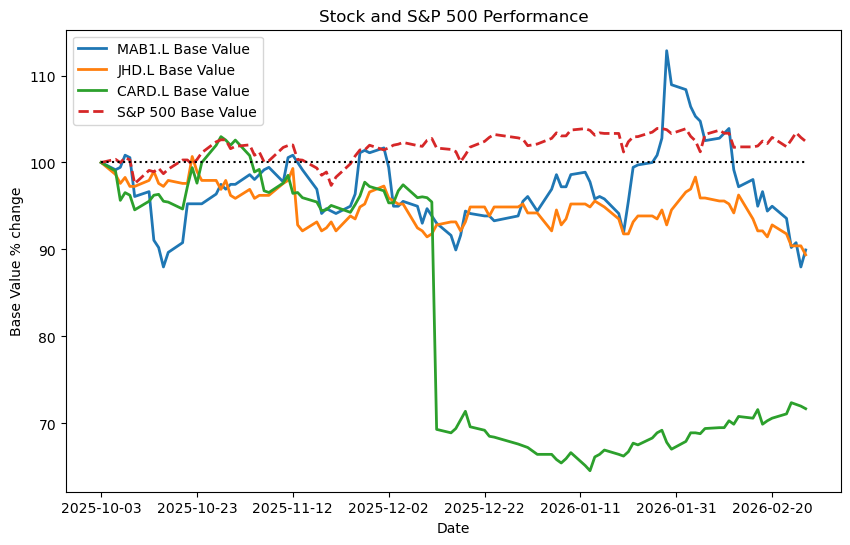

In [13]:
plot_results(data_031025, ticker_031025, 20)

October 10th 2025

In [14]:
ticker_101025 = {'TSCO.L':'Buy', 'CVS':'Hold', 'JDW.L':'Hold'}

In [15]:
data_101025 = data_collector(ticker_101025, '2025-10-10', datetime.date.today())

[*********************100%***********************]  3 of 3 completed
[*********************100%***********************]  1 of 1 completed


In [16]:
results_101025 = results_summary(data_101025, ticker_101025)
results_101025

,Return (%),Pick,SP Return (%)
TSCO.L,7.085566,Buy,2.05311
CVS,3.909873,Hold,2.05311
JDW.L,13.060587,Hold,2.05311


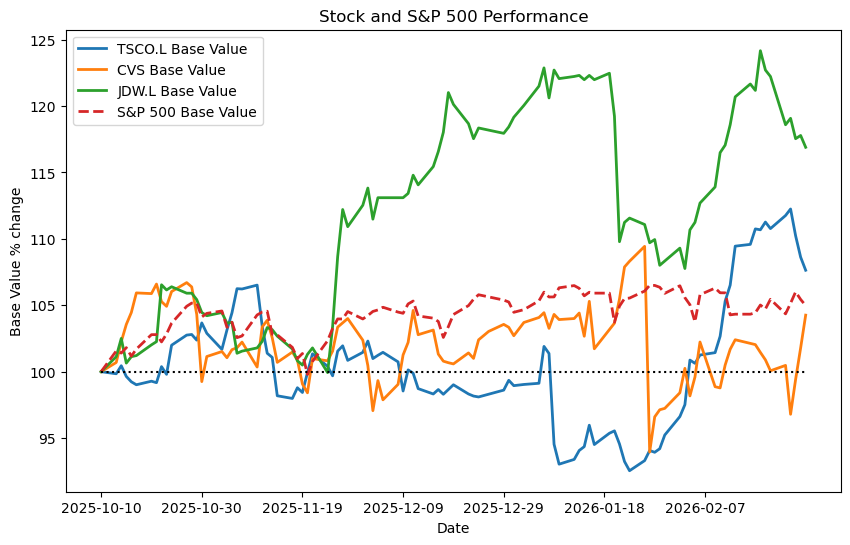

In [17]:
plot_results(data_101025, ticker_101025, 20)

October 17th 2025

In [18]:
ticker_171025 = {'FAN.L':'Buy', 'BWY.L':'Hold', 'THRL.L':'Buy'}

In [19]:
data_171025 = data_collector(ticker_171025, '2025-10-17', datetime.date.today())

[*********************100%***********************]  3 of 3 completed
[*********************100%***********************]  1 of 1 completed


In [20]:
results_171025 = results_summary(data_171025, ticker_171025)
results_171025

,Return (%),Pick,SP Return (%)
FAN.L,15.038286,Buy,4.016317
BWY.L,9.103242,Hold,4.016317
THRL.L,11.283079,Buy,4.016317


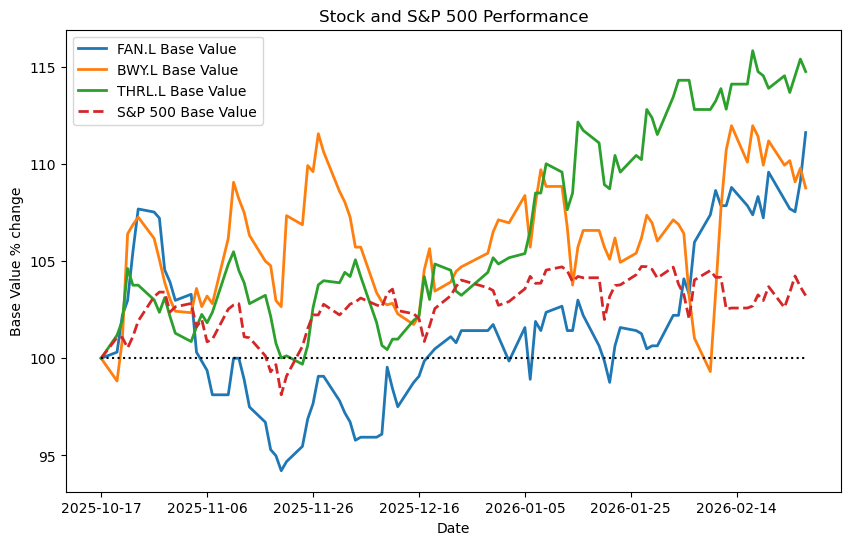

In [21]:
plot_results(data_171025, ticker_171025, 20)

October 24th 2025

In [22]:
ticker_241025 = {'SCT.L':'Buy', 'BMY.L':'Sell', 'WTB.L':'Hold'}

In [23]:
data_241025 = data_collector(ticker_241025, '2025-10-24', datetime.date.today())

[*********************100%***********************]  3 of 3 completed
[*********************100%***********************]  1 of 1 completed


In [24]:
results_241025 = results_summary(data_241025, ticker_241025)
results_241025

,Return (%),Pick,SP Return (%)
SCT.L,-30.683088,Buy,1.577214
BMY.L,10.954161,Sell,1.577214
WTB.L,-18.10045,Hold,1.577214


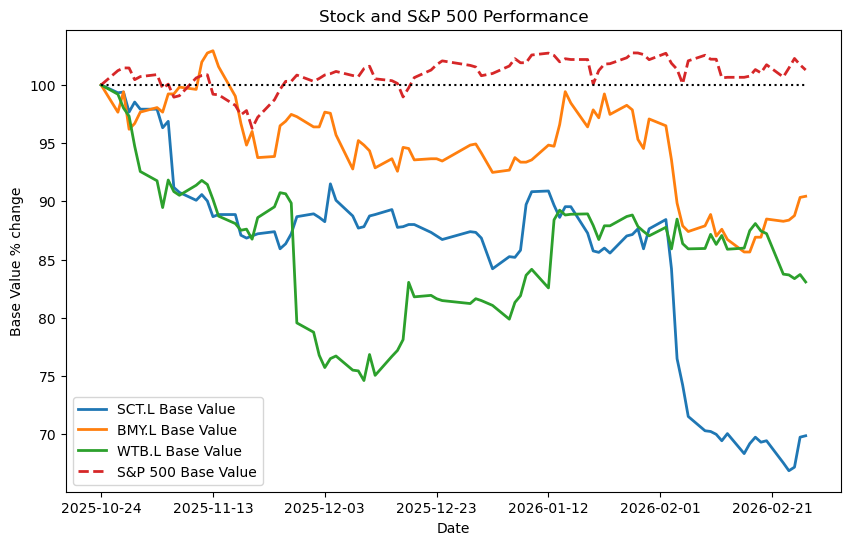

In [25]:
plot_results(data_241025, ticker_241025, 20)

October 31st 2025

In [26]:
ticker_311025 = {'AAF.L':'Hold', 'CCR.L':'Buy', 'ULTP.L':'Hold'}

In [27]:
data_311025 = data_collector(ticker_311025, '2025-10-31', datetime.date.today())

[*********************100%***********************]  3 of 3 completed
[*********************100%***********************]  1 of 1 completed


In [28]:
results_311025 = results_summary(data_311025, ticker_311025)
results_311025

,Return (%),Pick,SP Return (%)
AAF.L,27.103236,Hold,-0.004216
CCR.L,-12.356517,Buy,-0.004216
ULTP.L,-14.000919,Hold,-0.004216


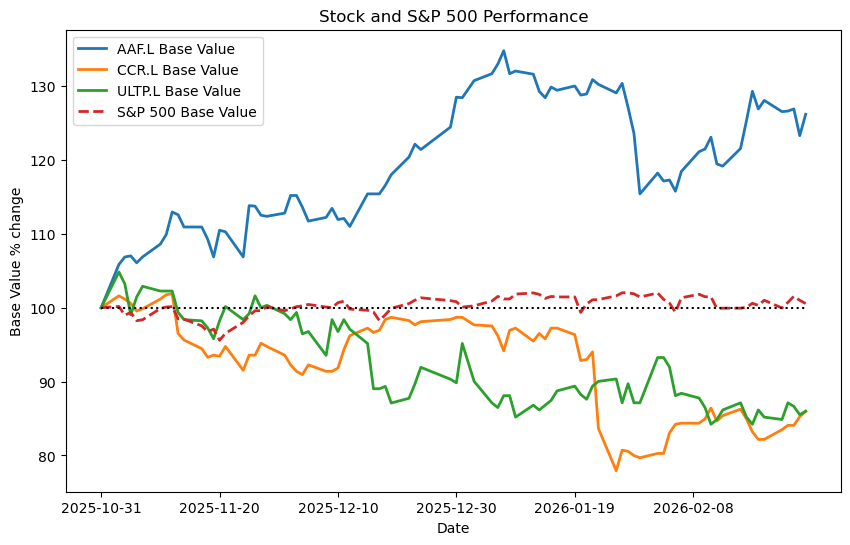

In [29]:
plot_results(data_311025, ticker_311025, 20)

November 7th 2025

In [30]:
ticker_071125 = {'AUTO.L':'Buy', 'TUNE.L':'Buy', 'ABF.L':'Hold'}

In [31]:
data_071125 = data_collector(ticker_071125, '2025-11-07', datetime.date.today())

[*********************100%***********************]  3 of 3 completed
[*********************100%***********************]  1 of 1 completed


In [32]:
results_071125 = results_summary(data_071125, ticker_071125)
results_071125

,Return (%),Pick,SP Return (%)
AUTO.L,-38.07388,Buy,2.728417
TUNE.L,-6.112468,Buy,2.728417
ABF.L,-12.115878,Hold,2.728417


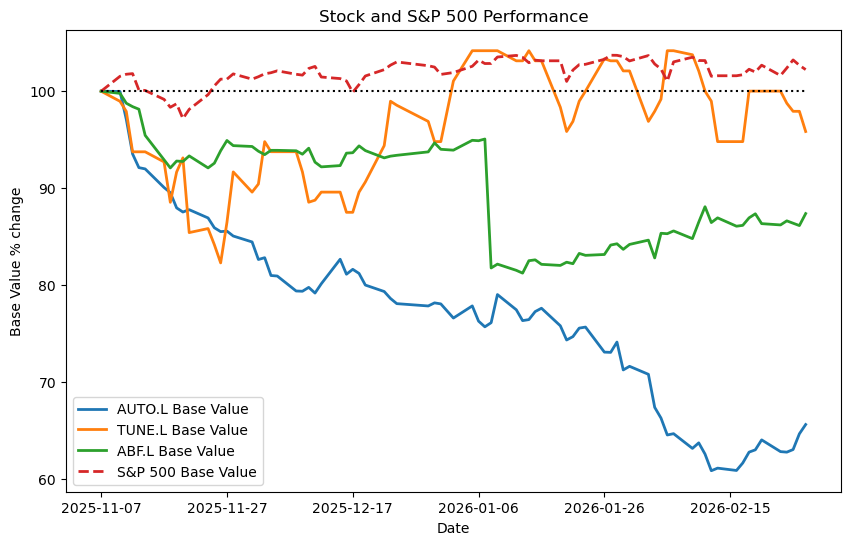

In [33]:
plot_results(data_071125, ticker_071125, 20)

November 14th 2025

In [34]:
ticker_141125 = {'APN.L':'Buy', 'OXIG.L':'Buy', 'VOD':'Hold'}

In [35]:
data_141125 = data_collector(ticker_141125, '2025-11-14', datetime.date.today())

[*********************100%***********************]  3 of 3 completed
[*********************100%***********************]  1 of 1 completed


In [36]:
results_141125 = results_summary(data_141125, ticker_141125)
results_141125

,Return (%),Pick,SP Return (%)
APN.L,44.476744,Buy,3.098552
OXIG.L,26.319267,Buy,3.098552
VOD,26.96634,Hold,3.098552


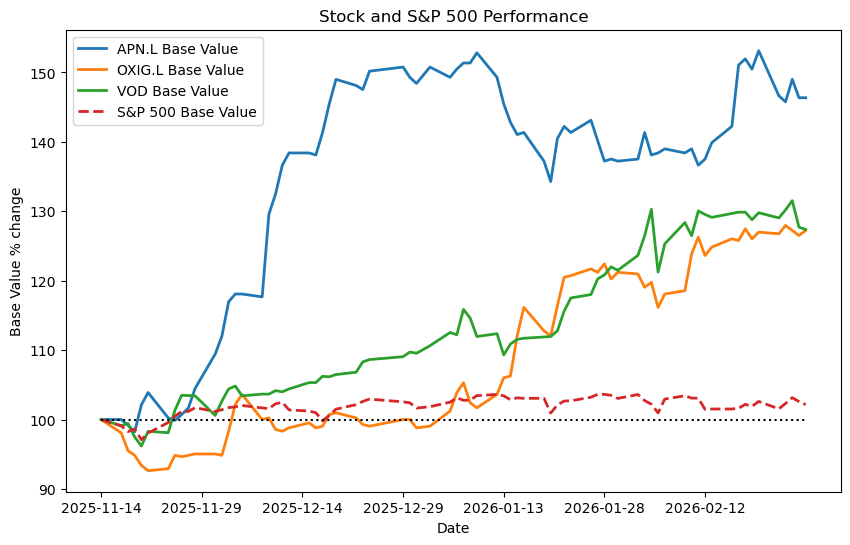

In [37]:
plot_results(data_141125, ticker_141125, 15)

November 21st 2025

In [38]:
ticker_211125 = {'GPE.L':'Buy', 'GNC.L':'Buy', 'G4M.L':'Hold'}

In [39]:
data_211125 = data_collector(ticker_211125, '2025-11-21', datetime.date.today())

[*********************100%***********************]  3 of 3 completed
[*********************100%***********************]  1 of 1 completed


In [40]:
results_211125 = results_summary(data_211125, ticker_211125)
results_211125

,Return (%),Pick,SP Return (%)
GPE.L,13.78083,Buy,4.928633
GNC.L,17.148991,Buy,4.928633
G4M.L,-1.973684,Hold,4.928633


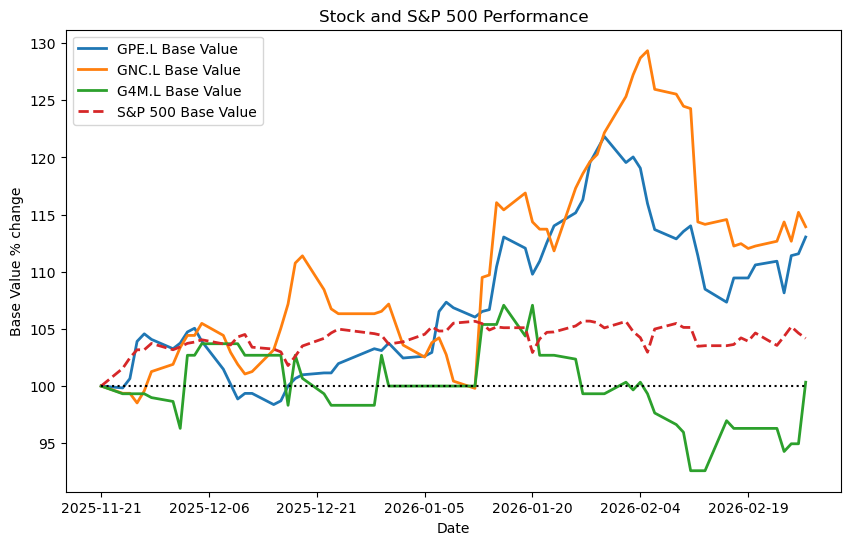

In [41]:
plot_results(data_211125, ticker_211125, 15)

November 28th 2025

In [42]:
ticker_281125 = {'HLMA.L':'Buy', 'EZJ.L':'Buy', 'RNWH.L':'Hold'}

In [43]:
data_281125 = data_collector(ticker_281125, '2025-11-28', datetime.date.today())

[*********************100%***********************]  3 of 3 completed
[*********************100%***********************]  1 of 1 completed


In [44]:
results_281125 = results_summary(data_281125, ticker_281125)
results_281125

,Return (%),Pick,SP Return (%)
HLMA.L,17.46533,Buy,0.826086
EZJ.L,-6.520761,Buy,0.826086
RNWH.L,0.229424,Hold,0.826086


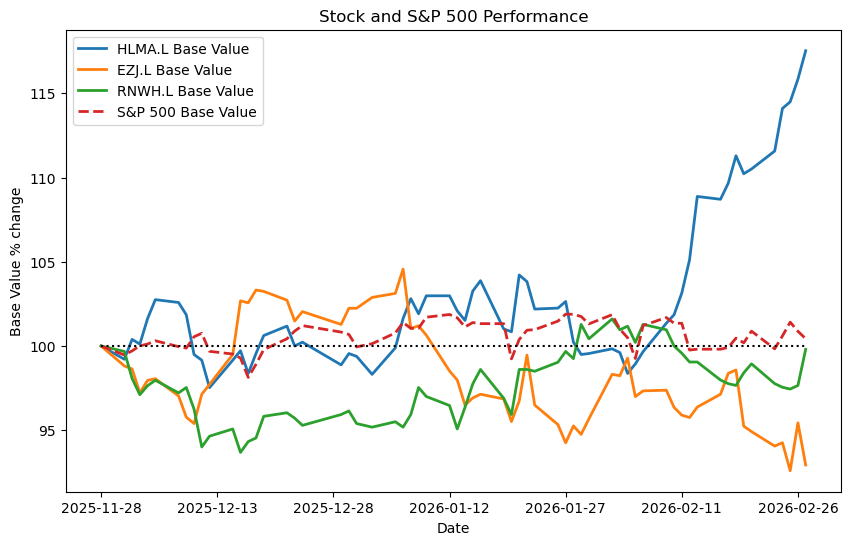

In [45]:
plot_results(data_281125, ticker_281125, 15)

December 12th 2025

In [46]:
ticker_121225 = {'CHG.L': 'Buy', 'GTLY.L':'Hold', 'MOON.L':'Buy'}

In [47]:
data_121225 = data_collector(ticker_121225, '2025-12-12', datetime.date.today())

[*********************100%***********************]  3 of 3 completed
[*********************100%***********************]  1 of 1 completed


In [48]:
results_121225 = results_summary(data_121225, ticker_121225)
results_121225

,Return (%),Pick,SP Return (%)
CHG.L,15.210356,Buy,-0.115731
GTLY.L,-25.794535,Hold,-0.115731
MOON.L,10.950334,Buy,-0.115731


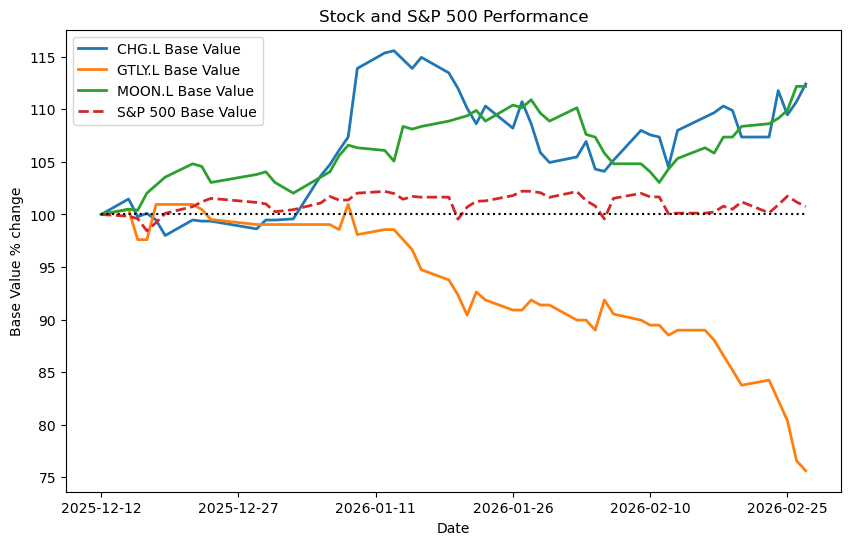

In [49]:
plot_results(data_121225, ticker_121225, 15)

December 19th 2025

In [50]:
ticker_191225 = {'BKG.L': 'Buy', 'VCP.L':'Sell', 'GDWN.L':'Hold'}

In [51]:
data_191225 = data_collector(ticker_191225, '2025-12-25', datetime.date.today())

[*********************100%***********************]  3 of 3 completed
[*********************100%***********************]  1 of 1 completed


In [52]:
results_191225 = results_summary(data_191225, ticker_191225)
results_191225

,Return (%),Pick,SP Return (%)
BKG.L,11.731266,Buy,-0.358077
VCP.L,30.855544,Sell,-0.358077
GDWN.L,17.475728,Hold,-0.358077


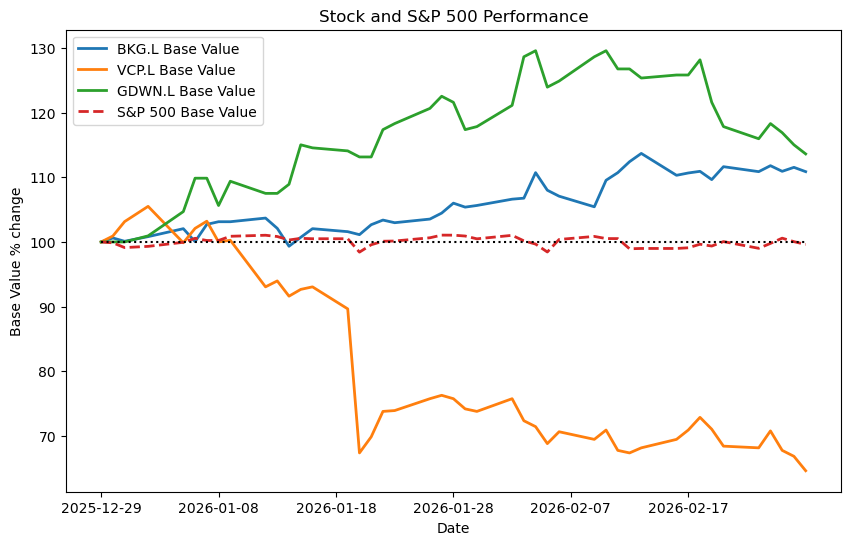

In [53]:
plot_results(data_191225, ticker_191225, 10)

January 16th 2026

In [54]:
ticker_160126 = {'GMWKF': 'Buy', 'KGH.L': 'Hold', 'MSI.L': 'Buy'}

In [55]:
data_160126 = data_collector(ticker_160126, '2026-01-16', datetime.date.today())

[*********************100%***********************]  3 of 3 completed
[*********************100%***********************]  1 of 1 completed


In [56]:
results_160126 = results_summary(data_160126, ticker_160126)
results_160126

,Return (%),Pick,SP Return (%)
GMWKF,-7.92016,Buy,-1.173187
KGH.L,-17.359759,Hold,-1.173187
MSI.L,-10.032597,Buy,-1.173187


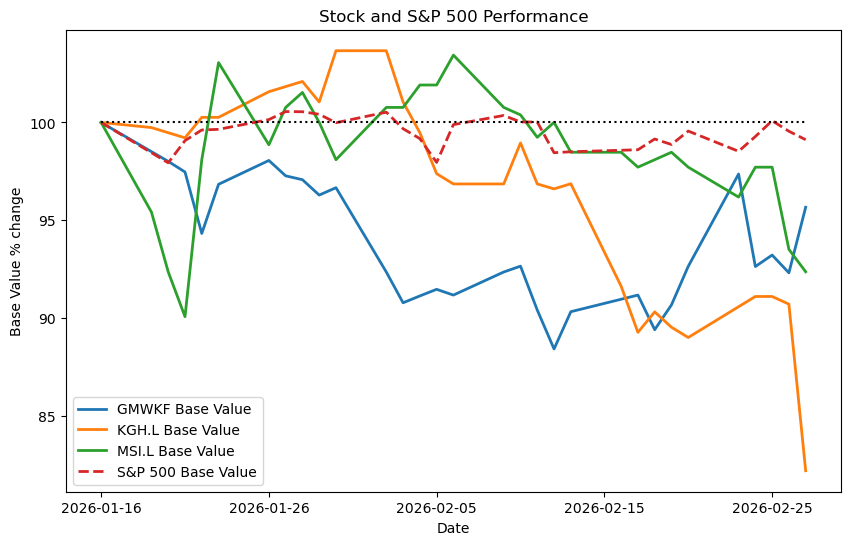

In [57]:
plot_results(data_160126, ticker_160126, 10)

January 23rd 2026

In [58]:
ticker_230126 = {'RAT.L': 'Buy', 'TET.L':'Hold', 'SAFE.L':'Hold'}

In [59]:
data_230126 = data_collector(ticker_230126, '2026-01-23', datetime.date.today())

[*********************100%***********************]  3 of 3 completed
[*********************100%***********************]  1 of 1 completed


In [60]:
results_230126 = results_summary(data_230126, ticker_230126)
results_230126

,Return (%),Pick,SP Return (%)
RAT.L,5.841121,Buy,-0.419381
TET.L,-0.938967,Hold,-0.419381
SAFE.L,-0.376884,Hold,-0.419381


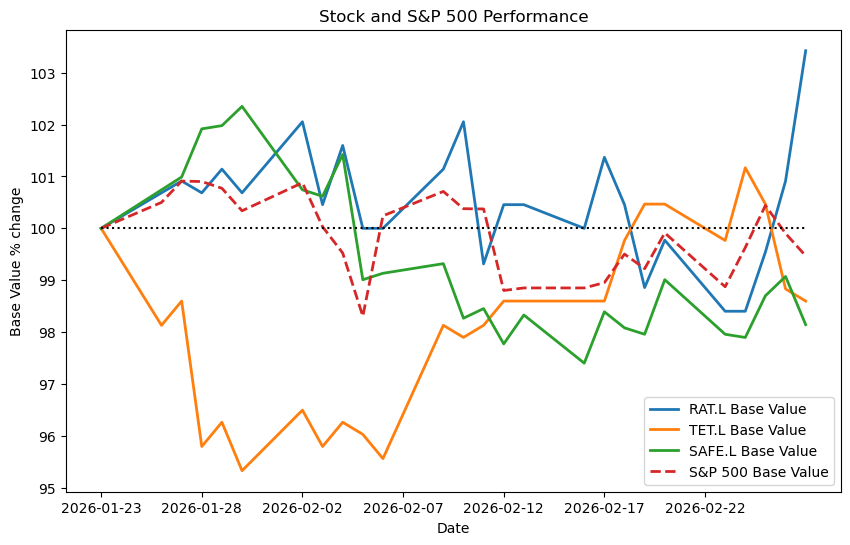

In [61]:
plot_results(data_230126, ticker_230126, 5)

January 30th 2026

In [62]:
ticker_300126 = {'ILIKF':'Hold', 'MSFT':'Buy', 'GE':'Hold'}

In [63]:
data_300126 = data_collector(ticker_300126, '2026-01-30', datetime.date.today())

[*********************100%***********************]  3 of 3 completed
[*********************100%***********************]  1 of 1 completed


In [64]:
results_300126 = results_summary(data_300126, ticker_300126)
results_300126

,Return (%),Pick,SP Return (%)
ILIKF,0.508907,Hold,-0.984417
MSFT,-10.368104,Buy,-0.984417
GE,15.239061,Hold,-0.984417


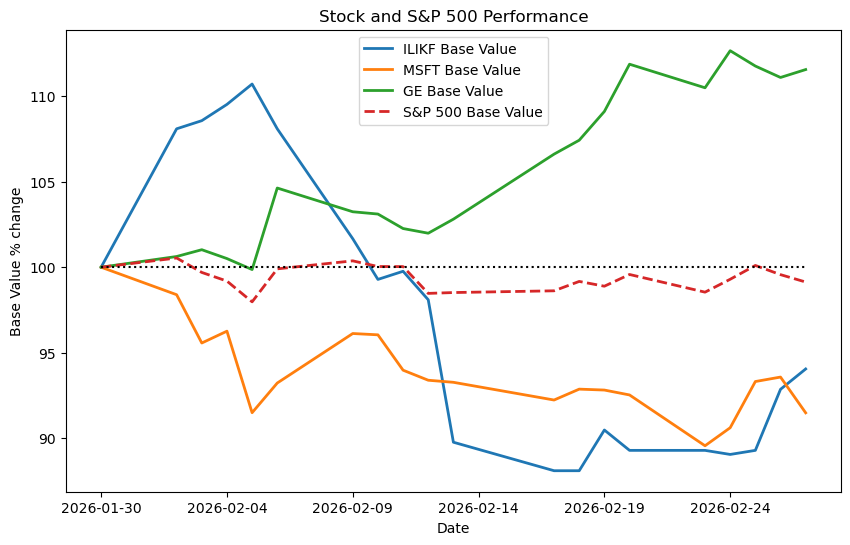

In [65]:
plot_results(data_300126, ticker_300126, 5)

Feburary 6th 2026

In [66]:
tickers_060226= {'WOSG.L': 'Buy', 'LBG.L':'Buy', 'FLTCF':'Hold'}

In [67]:
data_060226 = data_collector(tickers_060226, '2026-02-06', datetime.date.today())

[*********************100%***********************]  3 of 3 completed
[*********************100%***********************]  1 of 1 completed


In [68]:
results_060226 = results_summary(data_060226, tickers_060226)
results_060226

,Return (%),Pick,SP Return (%)
WOSG.L,4.115732,Buy,0.911574
LBG.L,-2.692306,Buy,0.911574
FLTCF,-0.359712,Hold,0.911574


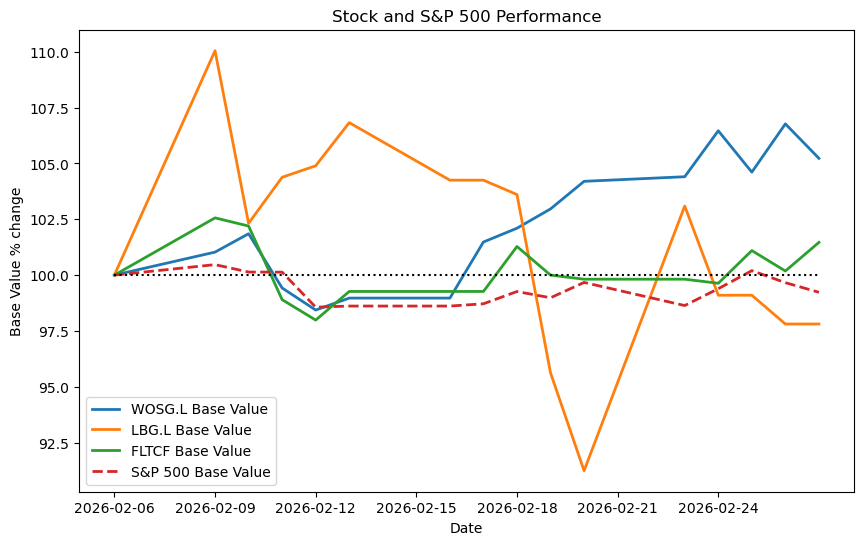

In [69]:
plot_results(data_060226, tickers_060226, 3)

Feburary 13th 2026

In [70]:
tickers_130226 = {'BCS': 'Buy', 'BP': 'Hold', 'DNLM.L': 'Sell'}

In [71]:
data_130226 = data_collector(tickers_130226, '2026-02-13', datetime.date.today())

[*********************100%***********************]  3 of 3 completed
[*********************100%***********************]  1 of 1 completed


In [72]:
results_130226 = results_summary(data_130226, tickers_130226)
results_130226

,Return (%),Pick,SP Return (%)
BCS,0.126877,Buy,0.652738
BP,5.844378,Hold,0.652738
DNLM.L,-6.329114,Sell,0.652738


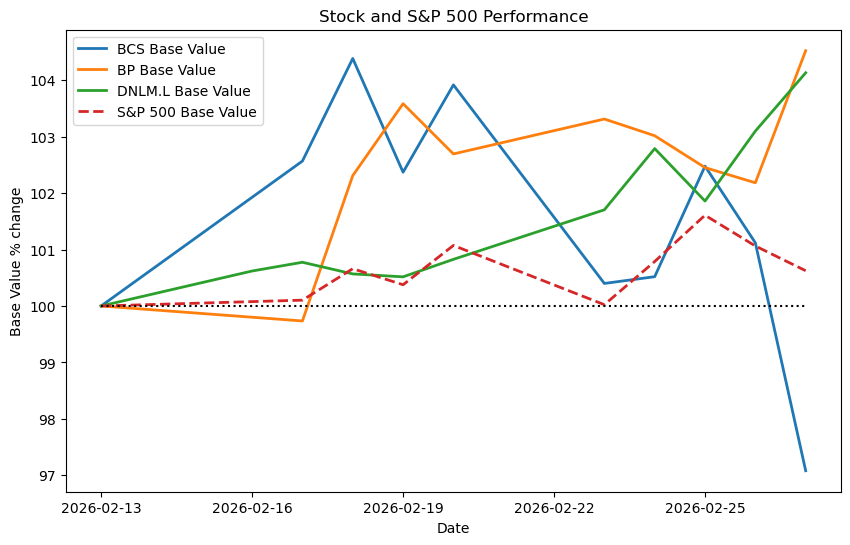

In [73]:
plot_results(data_130226, tickers_130226, 3)

Feburary 20th 2026

In [74]:
tickers_200226 = {'BHP':'Buy', 'BAESY':'Hold', 'NWG':'Hold'}

In [75]:
data_200226 = data_collector(tickers_200226, '2026-02-20', datetime.date.today())

[*********************100%***********************]  3 of 3 completed
[*********************100%***********************]  1 of 1 completed


In [76]:
results_200226 = results_summary(data_200226, tickers_200226)
results_200226

,Return (%),Pick,SP Return (%)
BHP,9.138349,Buy,0.520514
BAESY,-0.154932,Hold,0.520514
NWG,-1.833232,Hold,0.520514


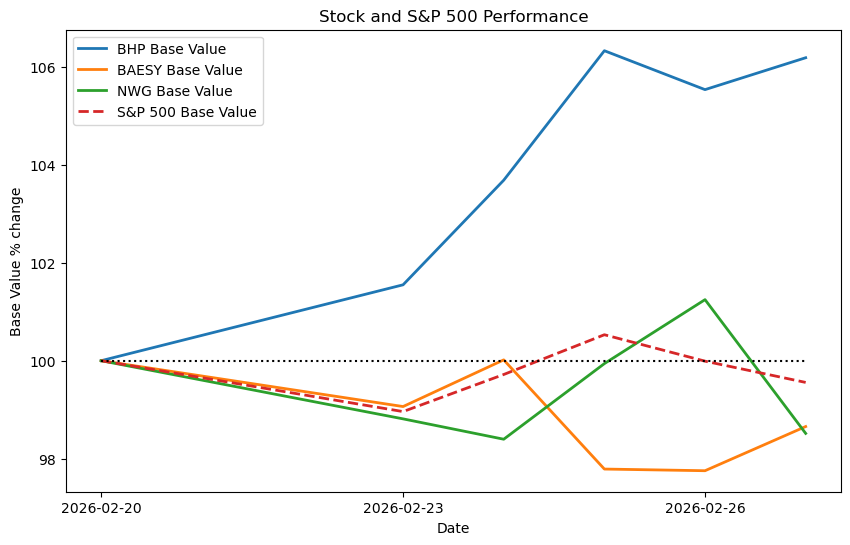

In [77]:
plot_results(data_200226, tickers_200226, 3)

Feburary 27th 2026

In [78]:
ticker_270226 = {'CNA.L':'Buy', 'MONY.L':'Buy', 'DEO':'Hold'}

In [79]:
data_270226 = data_collector(ticker_270226, '2026-02-27', datetime.date.today())

[*********************100%***********************]  3 of 3 completed
[*********************100%***********************]  1 of 1 completed


In [80]:
results_270226 = results_summary(data_270226, ticker_270226)
results_270226

,Return (%),Pick,SP Return (%)
CNA.L,1.710925,Buy,0.325818
MONY.L,1.714958,Buy,0.325818
DEO,2.099015,Hold,0.325818


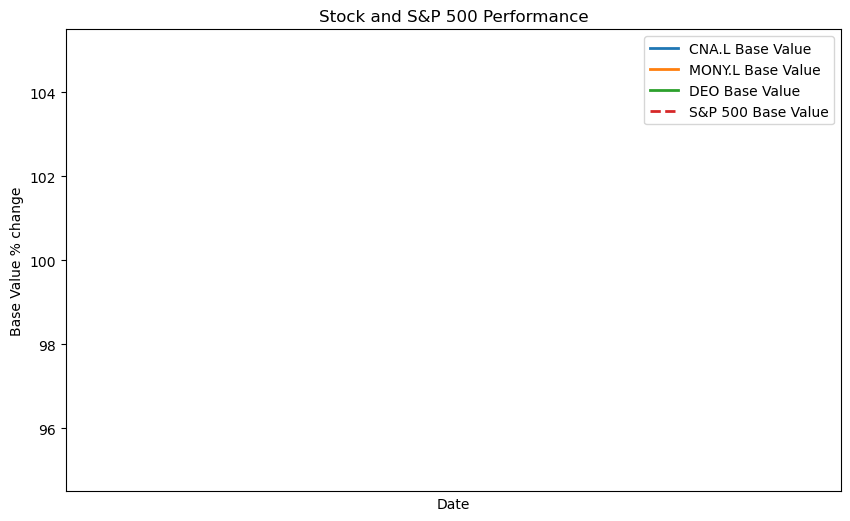

In [81]:
plot_results(data_270226, ticker_270226, 3)

Complete Table

In [82]:
result_list = [results_031025, results_101025, results_171025, results_241025, results_311025, results_071125, results_141125, results_211125, results_281125, results_121225, results_191225, results_160126, results_230126, results_300126, results_060226, results_130226, results_200226, results_270226]
key_list = ['2025-10-03', '2025-10-10', '2025-10-17', '2025-10-24', '2025-10-31', '2025-11-07', '2025-11-14', '2025-11-21', '2025-11-28', '2025-12-12', '2025-12-19' ,'2026-01-16', '2026-01-23', '2026-01-30', '2026-02-06', '2026-02-13', '2026-02-20', '2026-02-27']
all_results = merge_and_evaluate(result_list, key_list, tol=1.0)
#all_results

In [83]:
hit_rate = all_results['Success'].mean() * 100
print(f"Overall Hit Rate: {hit_rate:.2f}%")

Overall Hit Rate: 40.74%


In [84]:
buy_hit_rate = all_results[all_results['Pick'] == 'Buy']['Success'].mean()*100
print(f"Buy Hit Rate: {buy_hit_rate:.2f}%")

Buy Hit Rate: 57.14%


In [85]:
hold_hit_rate = all_results[all_results['Pick'] == 'Hold']['Success'].mean()*100
print(f"Hold Hit Rate: {hold_hit_rate:.2f}%")

Hold Hit Rate: 17.39%


In [86]:
sell_hit_rate = all_results[all_results['Pick'] == 'Sell']['Success'].mean()*100
print(f"Sell Hit Rate: {sell_hit_rate:.2f}%")

Sell Hit Rate: 66.67%


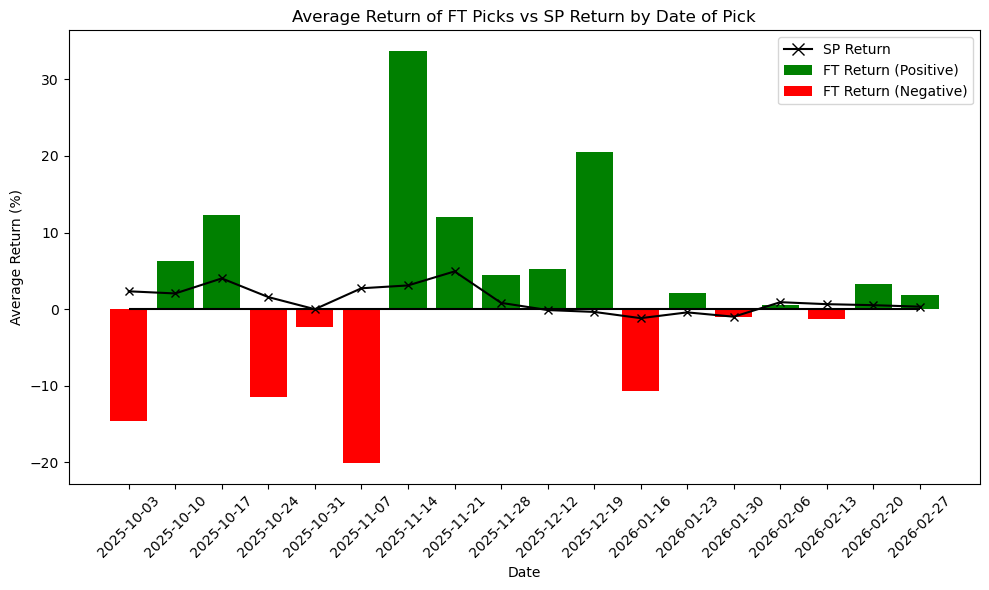

In [87]:
plot_all_results(all_results, key_list, 0.4, 0.4, 0.2)

In [88]:
ft_avg_returns = []
sp_avg_returns = []
for date in key_list:
    ft_avg_return, avg_sp_return = performance_by_date(all_results, date, 0.4, 0.4, 0.2)
    ft_avg_returns.append(ft_avg_return)
    sp_avg_returns.append(avg_sp_return)

In [89]:
ft_ret = np.mean(ft_avg_returns)
sp_ret = np.mean(sp_avg_returns)
print(f"FT return: {ft_ret:.2f}%, SP return: {sp_ret:.2f}% since {key_list[0]}") #weekly dca vs ft

FT return: 2.26%, SP return: 1.16% since 2025-10-03
